## Notation
Here is a summary of some of the notation you will encounter.  

|General <img width=70/> <br />  Notation  <img width=70/> | Description<img width=350/>| Python (if applicable) |
|:------------|:------------------------------------------------------------|:------------|
| $a$ | scalar, non bold | |
| $\mathbf{a}$ | vector, bold | |
| **Regression** | | |
|  $\mathbf{x}$ | Training Example feature values (in this lab - Size (1000 sqft))  | `x_train` |
|  $\mathbf{y}$  | Training Example  targets (in this lab Price (1000s of dollars))  | `y_train` |
|  $x^{(i)}$, $y^{(i)}$ | $i_{th}$Training Example | `x_i`, `y_i`|
| m | Number of training examples | `m`|
|  $w$  |  parameter: weight                                 | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |
| $f_{w,b}(x^{(i)})$ | The result of the model evaluation at $x^{(i)}$ parameterized by $w,b$: $f_{w,b}(x^{(i)}) = wx^{(i)}+b$  | `f_wb` |


In [91]:
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use('/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/week3_ml_core/deeplearning.mplstyle')

In [92]:
# x_train is the input variable
x_train = np.array([1.0, 2.0])

# y_train is the target
y_train = np.array([300.0, 500.0])

In [93]:
# m is the number of training example
## using .shape
m = x_train.shape[0]
## using len()
m = len(x_train)
print(f"Number of training examples is {m}")

Number of training examples is 2


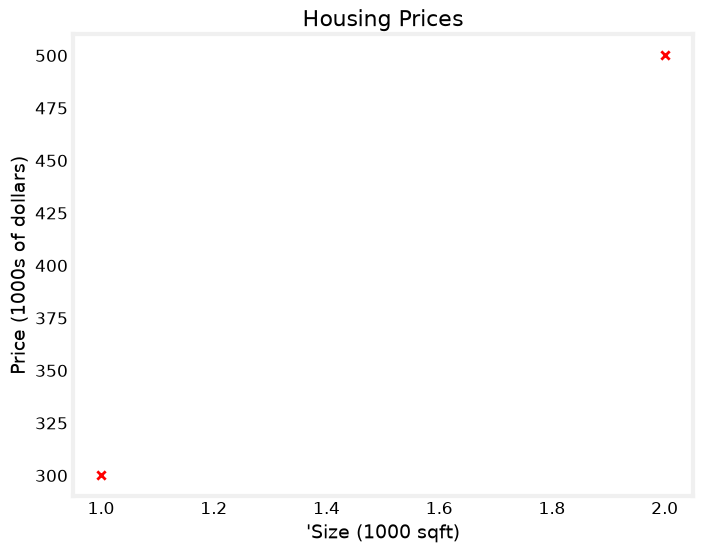

In [94]:
# scatter plot where x_train is the input variable and y_train is the target, 
# marker is 'x' and color is red
plt.scatter(x_train, y_train, marker='x', c='r')

plt.title("Housing Prices")
plt.xlabel("'Size (1000 sqft)")
plt.ylabel("Price (1000s of dollars)")
plt.show()

In [95]:
w = 100
b = 100

def compute_model_output(x,w,b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

temp_f_wb = compute_model_output(x_train, w, b)

f_wb: [200. 300.]


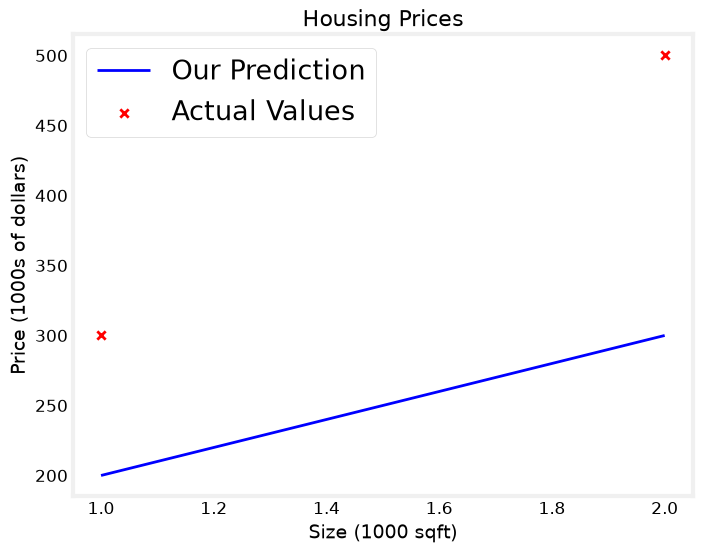

In [96]:
plt.plot(x_train, temp_f_wb, c='b', label = 'Our Prediction')
print(f"f_wb: {temp_f_wb}")

plt.scatter(x_train, y_train, marker='x', c='r', label = 'Actual Values')
plt.title("Housing Prices")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (1000s of dollars)")
plt.legend()
plt.show()

In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$

$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

In [97]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = w * x[i] + b
        cost += (f_wb_i - y[i]) ** 2
    total_cost = cost / (2 * m)
    return total_cost

In [98]:
import math, copy

The gradient is defined as:
$$
\begin{align*}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \\
\frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})
\end{align*}
$$ (4)(5)

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

<a name="toc_40291_2.3"></a>
### compute_gradient
<a name='ex-01'></a>
`compute_gradient`  implements (4) and (5) above and returns $\frac{\partial J(w,b)}{\partial w}$,$\frac{\partial J(w,b)}{\partial b}$. The embedded comments describe the operations.

In [99]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]          # m = number of training examples
    dj_dw = 0                # will accumulate sum_i (f_wb - y_i) * x_i
    dj_db = 0                # will accumulate sum_i (f_wb - y_i)

    for i in range(m):
        f_wb = w * x[i] + b              # f_wb = model prediction, f_{w,b}(x^(i)) = w*x^(i) + b

        dj_dw_i = (f_wb - y[i] * x[i])   # <- check this line against the formula above.
                                          #    is this computing (f_wb - y_i) * x_i,
                                          #    or f_wb - (y_i * x_i)? does that match dJ/dw?

        dj_db_i = f_wb - y[i]            # error term: (f_wb - y_i), matches dJ/db summand exactly

        dj_db += dj_db_i                 # accumulate sum_i (f_wb - y_i)
        dj_dw += dj_dw_i                 # accumulate sum_i (...)

    dj_dw = dj_dw / m                    # divide by m -> average -> completes dJ/dw
    dj_db = dj_db / m                    # divide by m -> average -> completes dJ/db

    return dj_dw, dj_db

## Implement Gradient Descent
You will implement gradient descent algorithm for one feature. You will need three functions. 
- `compute_gradient` implementing equation (4) and (5) above
- `compute_cost` implementing equation (2) above (code from previous lab)
- `gradient_descent`, utilizing compute_gradient and compute_cost

<a name="toc_40291_2.5"></a>
###  Gradient Descent
Now that gradients can be computed,  gradient descent, described in equation (3) above can be implemented below in `gradient_descent`. The details of the implementation are described in the comments. Below, you will utilize this function to find optimal values of $w$ and $b$ on the training data.

In lecture, *gradient descent* was described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  

In [100]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 1000: Cost 1.42e+05  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  1.221e+03, b:-1.28150e+03
Iteration 2000: Cost 5.22e+05  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  2.221e+03, b:-2.78150e+03
Iteration 3000: Cost 1.15e+06  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  3.221e+03, b:-4.28150e+03
Iteration 4000: Cost 2.03e+06  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  4.221e+03, b:-5.78150e+03
Iteration 5000: Cost 3.16e+06  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  5.221e+03, b:-7.28150e+03
Iteration 6000: Cost 4.54e+06  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  6.221e+03, b:-8.78150e+03
Iteration 7000: Cost 6.17e+06  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  7.221e+03, b:-1.02815e+04
Iteration 8000: Cost 8.05e+06  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  8.221e+03, b:-1.17815e+04
Iteration 9000: Cost 1.02e+07  dj_dw: -1.000e+02, dj_db:  1.500e+02   w:  9.221e+03, b:-1.32815e+04


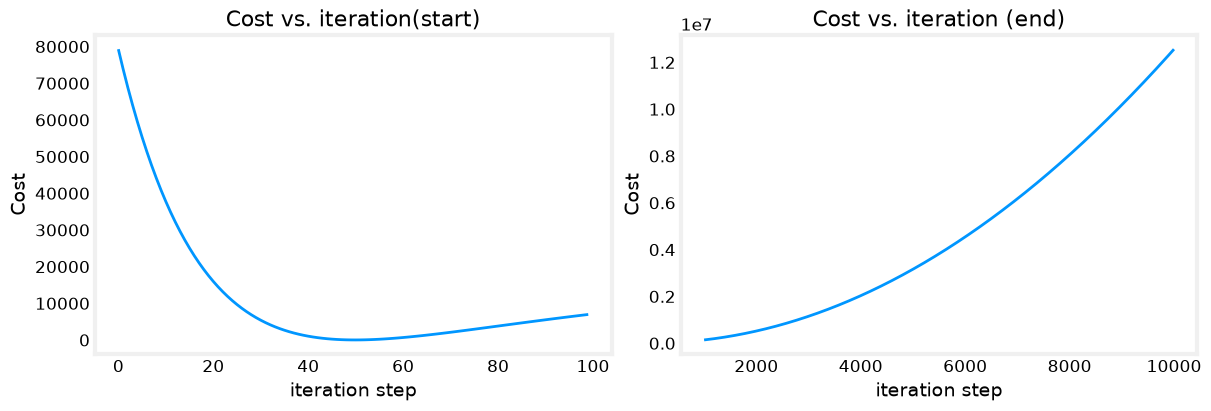

In [101]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [102]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction -4560.0 Thousand dollars
1200 sqft house prediction -2516.0 Thousand dollars
2000 sqft house prediction 5660.0 Thousand dollars


In [104]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 2.58e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  5.200e+02, b: 3.20000e+02
Iteration    1: Cost 8.02e+04  dj_dw:  4.500e+02, dj_db:  7.000e+02   w:  1.600e+02, b:-2.40000e+02
Iteration    2: Cost 2.74e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.800e+02, b: 8.00000e+01
Iteration    3: Cost 8.18e+04  dj_dw:  4.500e+02, dj_db:  7.000e+02   w:  3.200e+02, b:-4.80000e+02
Iteration    4: Cost 2.96e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  8.400e+02, b:-1.60000e+02
Iteration    5: Cost 8.98e+04  dj_dw:  4.500e+02, dj_db:  7.000e+02   w:  4.800e+02, b:-7.20000e+02
Iteration    6: Cost 3.25e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  1.000e+03, b:-4.00000e+02
Iteration    7: Cost 1.04e+05  dj_dw:  4.500e+02, dj_db:  7.000e+02   w:  6.400e+02, b:-9.60000e+02
Iteration    8: Cost 3.60e+05  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  1.160e+03, b:-6.40000e+02
Iteration    9: Cost 1.25e+05  dj_dw:  4.500e+02, dj_db:  7.000e+02   w:  8.000e+02, b:-1.20000e+03
